In [2]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
sns.set_style('darkgrid')

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [4]:
from statsmodels.tsa.arima.model import ARIMA

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Wine Quality

<Axes: >

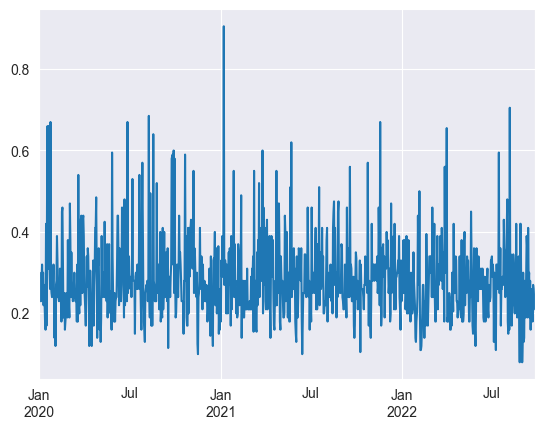

In [11]:
# Load wine quality dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
wine_df = pd.read_csv(url, sep=';')

# Use volatile acidity as time series (stationary, no trend/seasonality)
wine = wine_df['volatile acidity'].iloc[:1000].reset_index(drop=True)
wine.index = pd.date_range('2020-01-01', periods=len(wine), freq='D')

wine.plot()

# Shampoo Sales data

In [26]:
from sktime.datasets.forecasting import ShampooSales
y_shampoo = ShampooSales().load("y")

In [35]:
y_shampoo.index = [i.to_timestamp() for i in y_shampoo.index]

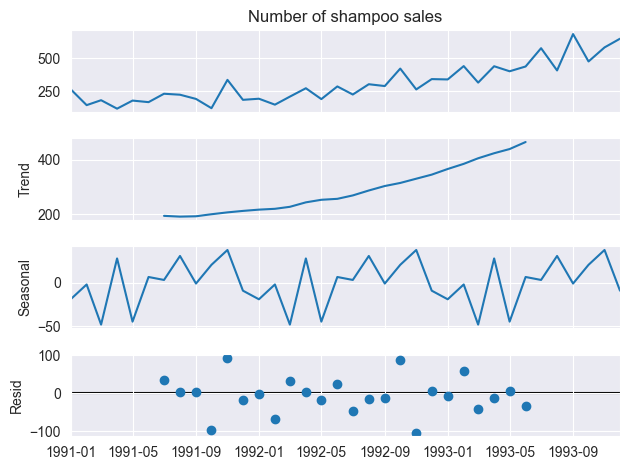

In [40]:
import statsmodels.tsa.api as smt
smt.seasonal_decompose(y_shampoo).plot();

In [41]:
pd.Series(data=smt.adfuller(y_shampoo), index="adf pvalue usedlag nobs critical icbest".split())

adf                                                  3.060142
pvalue                                                    1.0
usedlag                                                    10
nobs                                                       25
critical    {'1%': -3.7238633119999998, '5%': -2.98648896,...
icbest                                             278.997264
dtype: object

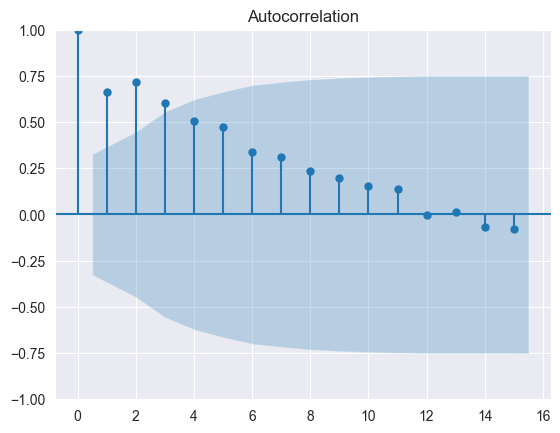

In [37]:
plot_acf(y_shampoo, lags=15);

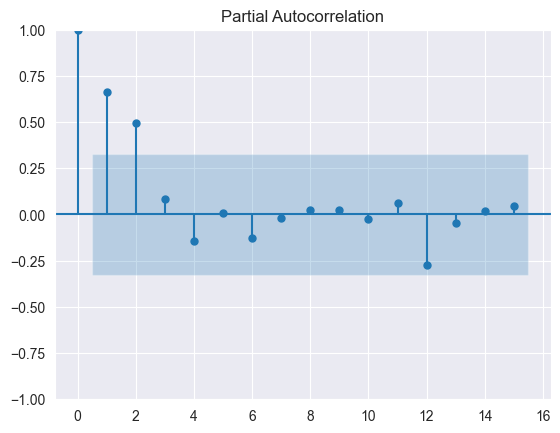

In [38]:
plot_pacf(y_shampoo, lags=15);

<big> This is the signature of an AR model

# CO2 Data

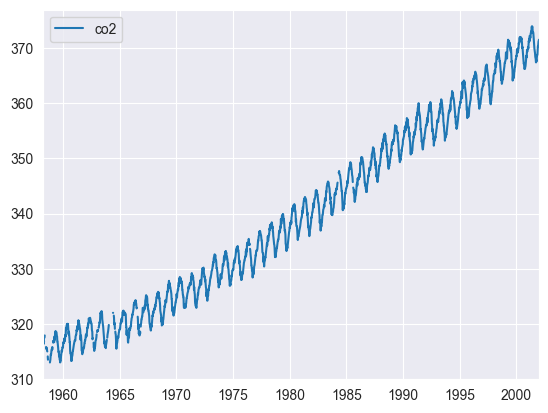

In [5]:
sm.datasets.co2.load_pandas().data.plot();

# Lynx DATA

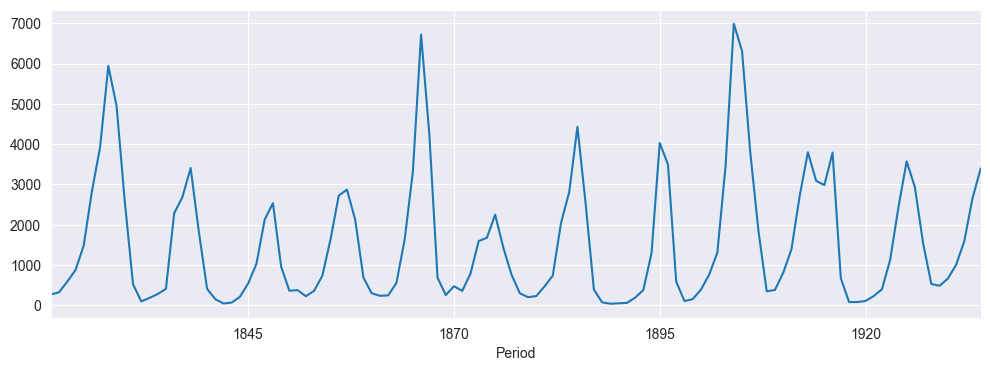

In [37]:
from sktime.datasets.forecasting import Lynx
Lynx().load("y").plot();

# Macroeconomic Data

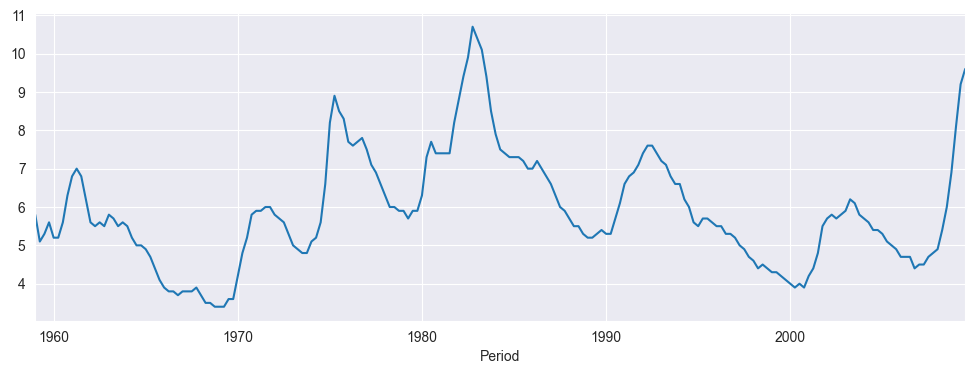

In [38]:
from sktime.datasets.forecasting import Macroeconomic
macro = Macroeconomic().load("y")  

macro['unemp'].plot();

# Sunspots Data

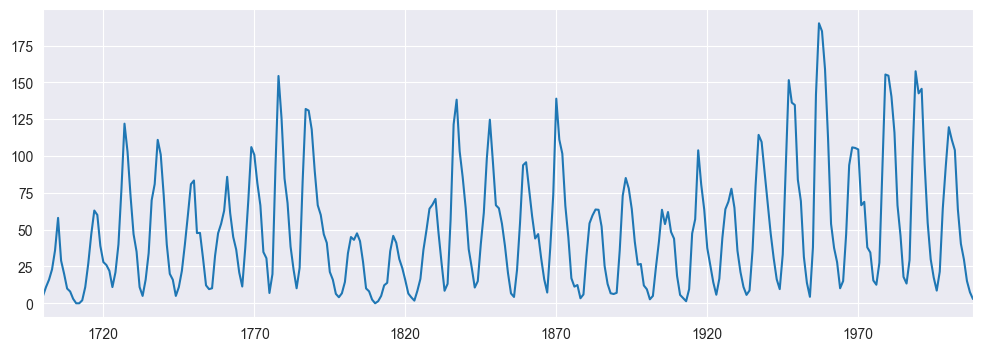

In [46]:
sunspots = sm.datasets.sunspots.load_pandas().data
sunspots.index = pd.Index(pd.date_range("1700", end="2009", freq="YE-DEC"))

sunspots.loc[:, 'SUNACTIVITY'].plot();

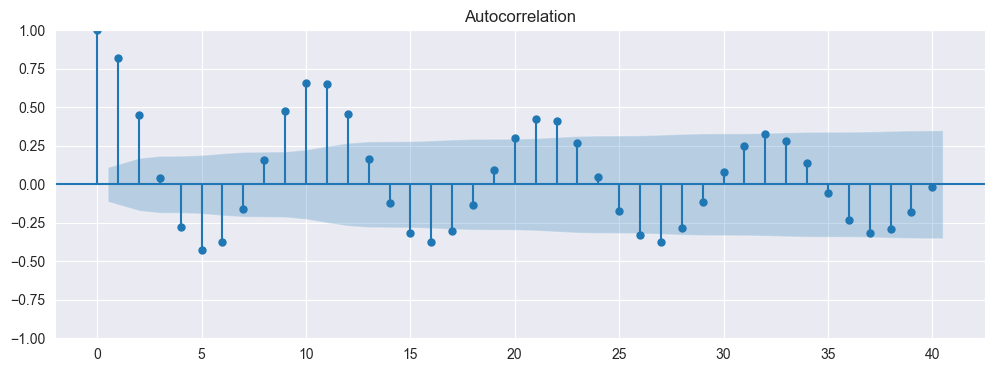

In [48]:
sm.graphics.tsa.plot_acf(sunspots['SUNACTIVITY'], lags=40);

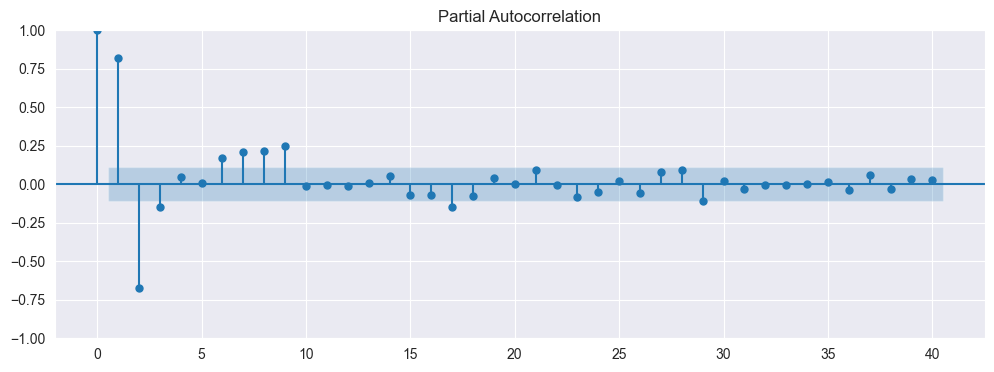

In [49]:
sm.graphics.tsa.plot_pacf(sunspots['SUNACTIVITY'], lags=40);

# BTC Price

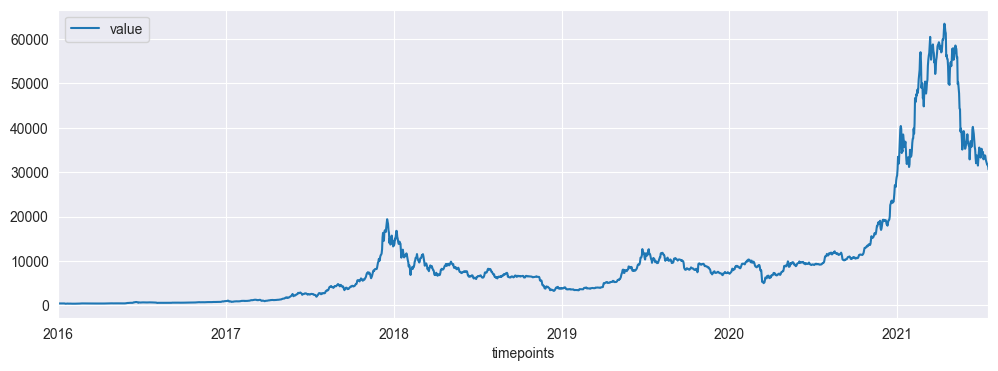

In [40]:
btc = ForecastingData(name="bitcoin_dataset_without_missing_values").load("y").reset_index().query("instances=='price'").set_index('timepoints').loc['2016':]

btc.plot();